# CodeAlpha Task 3 — Data Visualization
## Online Retail Dataset (UCI Machine Learning Repository)

**Author:** Ali Rashid (Chaudhary)
**Internship:** CodeAlpha Data Analytics Internship — Task 3 (Data Visualization)

---

### Objective

Transform the real Online Retail transactional dataset into clear, meaningful,
and visually compelling insights: 10 required visualizations, 2 advanced
visualizations, and 2 interactive Plotly visualizations, each answering a
specific analytical question and paired with a written interpretation.

### Dataset Description

| | |
|---|---|
| **Name** | Online Retail Dataset |
| **Source** | UCI Machine Learning Repository — `archive.ics.uci.edu/dataset/352/online+retail` |
| **Size** | 541,909 rows × 8 columns (raw) |
| **Period** | 1 December 2010 – 9 December 2011 |
| **Columns** | InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country |

This is the same dataset used in **Task 2 (EDA)**; this notebook builds a
standalone, visualization-focused deliverable and does not require any
Task 2 files to run — only the raw dataset placed in `data/raw/`.


## 1. Import Libraries

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import plotly.express as px

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)


## 2. Data Loading

In [2]:
DATA_PATH = Path("../data/raw/OnlineRetail.xlsx")
df = pd.read_excel(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")
df.head()


Loaded 541,909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data Preparation

Each transformation below is documented: what it does, and why. **No
information is destroyed without a flag preserving it.**


In [3]:
d = df.copy()
before = len(d)

# Cancellation flag (InvoiceNo starting with 'C')
d["InvoiceNo"] = d["InvoiceNo"].astype(str)
d["IsCancelled"] = d["InvoiceNo"].str.startswith("C")

# Remove exact duplicate rows (logging/export artifact)
dupes = int(d.duplicated().sum())
d = d.drop_duplicates()

# Missing Description: fill rather than drop
d["Description"] = d["Description"].fillna("UNKNOWN ITEM")

# Missing CustomerID: flag, do not drop (guest checkouts are real sales)
d["HasCustomerID"] = d["CustomerID"].notnull()

# Valid-sale flag: excludes cancellations and non-positive price/quantity
d["IsValidSale"] = (d["UnitPrice"] > 0) & (d["Quantity"] > 0) & (~d["IsCancelled"])

# Correct dtypes
d["StockCode"] = d["StockCode"].astype(str)
d["CustomerID"] = d["CustomerID"].astype("Int64")
d["Country"] = d["Country"].astype(str).str.strip()
d["InvoiceDate"] = pd.to_datetime(d["InvoiceDate"])

# Revenue
d["Revenue"] = d["Quantity"] * d["UnitPrice"]

# Date parts
d["Year"] = d["InvoiceDate"].dt.year
d["Month"] = d["InvoiceDate"].dt.month
d["Day"] = d["InvoiceDate"].dt.day
d["DayOfWeek"] = d["InvoiceDate"].dt.day_name()
d["Hour"] = d["InvoiceDate"].dt.hour
d["InvoiceMonth"] = d["InvoiceDate"].dt.to_period("M").astype(str)

print(f"Removed {dupes:,} exact duplicate rows ({dupes/before*100:.2f}% of raw data).")
print(f"Rows after cleaning: {len(d):,}")
print(f"Missing CustomerID: {(~d['HasCustomerID']).sum():,} rows ({(~d['HasCustomerID']).mean()*100:.2f}%)")
print(f"Cancelled rows: {d['IsCancelled'].sum():,} ({d['IsCancelled'].mean()*100:.2f}%)")

sales = d[d["IsValidSale"]].copy()
print(f"\nValid sales rows used for revenue-based charts: {len(sales):,}")


Removed 5,268 exact duplicate rows (0.97% of raw data).
Rows after cleaning: 536,641
Missing CustomerID: 135,037 rows (25.16%)
Cancelled rows: 9,251 (1.72%)



Valid sales rows used for revenue-based charts: 524,878


**Note:** `sales` (valid, non-cancelled, positively-priced/quantified
transactions) is used for revenue-based charts throughout this notebook.
The full flagged dataset `d` is used where cancellations themselves are
the subject of analysis (Section 8).


### Customer-Level Metrics

In [4]:
cust_sales = d[d["IsValidSale"] & d["HasCustomerID"]]
snapshot_date = cust_sales["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = cust_sales.groupby("CustomerID").agg(
    Orders=("InvoiceNo", "nunique"),
    Revenue=("Revenue", "sum"),
    LastPurchase=("InvoiceDate", "max"),
).reset_index()
cust["AvgOrderValue"] = (cust["Revenue"] / cust["Orders"]).round(2)
cust["Recency"] = (snapshot_date - cust["LastPurchase"]).dt.days

print(f"Customer-level metrics computed for {len(cust):,} customers.")
cust.head()


Customer-level metrics computed for 4,338 customers.


,CustomerID,Orders,Revenue,LastPurchase,AvgOrderValue,Recency
0,12346,1,77183.60,2011-01-18 10:01:00,77183.60,326
1,12347,7,4310.00,2011-12-07 15:52:00,615.71,2
2,12348,4,1797.24,2011-09-25 13:13:00,449.31,75
3,12349,1,1757.55,2011-11-21 09:51:00,1757.55,19
4,12350,1,334.40,2011-02-02 16:01:00,334.40,310


## 4. Exploratory Overview (KPIs)


In [5]:
total_revenue = float(sales["Revenue"].sum())
total_transactions = int(sales["InvoiceNo"].nunique())
total_customers = int(cust["CustomerID"].nunique())
avg_order_value = float(sales.groupby("InvoiceNo")["Revenue"].sum().mean())
cancellation_rate = float(d["IsCancelled"].mean() * 100)

print(f"Total Revenue:          £{total_revenue:,.2f}")
print(f"Total Transactions:     {total_transactions:,}")
print(f"Total Customers:        {total_customers:,}")
print(f"Average Order Value:    £{avg_order_value:,.2f}")
print(f"Cancellation Rate:      {cancellation_rate:.2f}%")


Total Revenue:          £10,642,110.80
Total Transactions:     19,960
Total Customers:        4,338
Average Order Value:    £533.17
Cancellation Rate:      1.72%


## 5. Visualizations

### 5.1 Revenue by Country


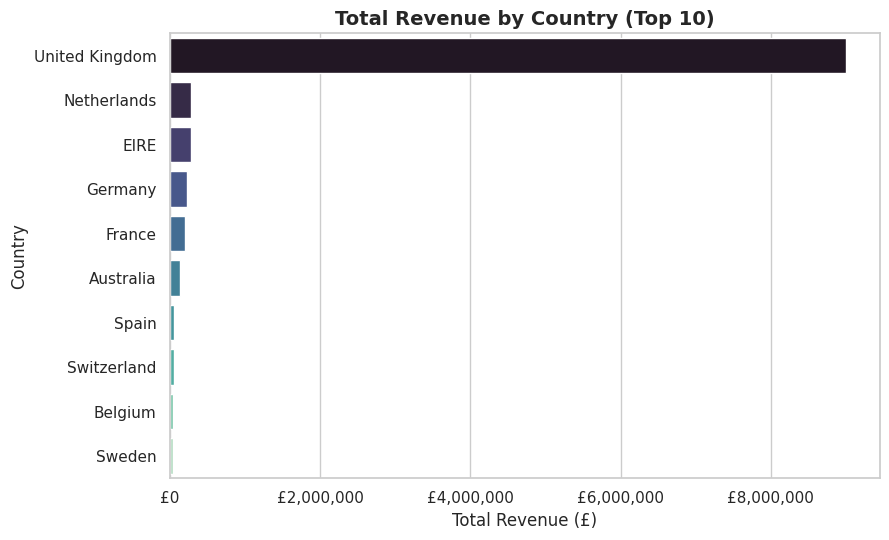

Top country: United Kingdom — 84.59% of total revenue


In [6]:
rev_by_country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5.5))
sns.barplot(x=rev_by_country.values, y=rev_by_country.index, hue=rev_by_country.index, palette="mako", legend=False)
plt.title("Total Revenue by Country (Top 10)", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

uk_share = rev_by_country.iloc[0] / sales["Revenue"].sum() * 100
print(f"Top country: {rev_by_country.index[0]} — {uk_share:.2f}% of total revenue")


**Interpretation:** Revenue is heavily concentrated in the United Kingdom,
which accounts for 84.59% of total revenue — consistent with this being a
UK-registered retailer, but also a geographic concentration risk: a
disruption in the UK market would affect the large majority of this
business's income, and the next-largest markets (Netherlands, EIRE,
Germany, France) represent a comparatively small but meaningful diversification
opportunity.


### 5.2 Top Products

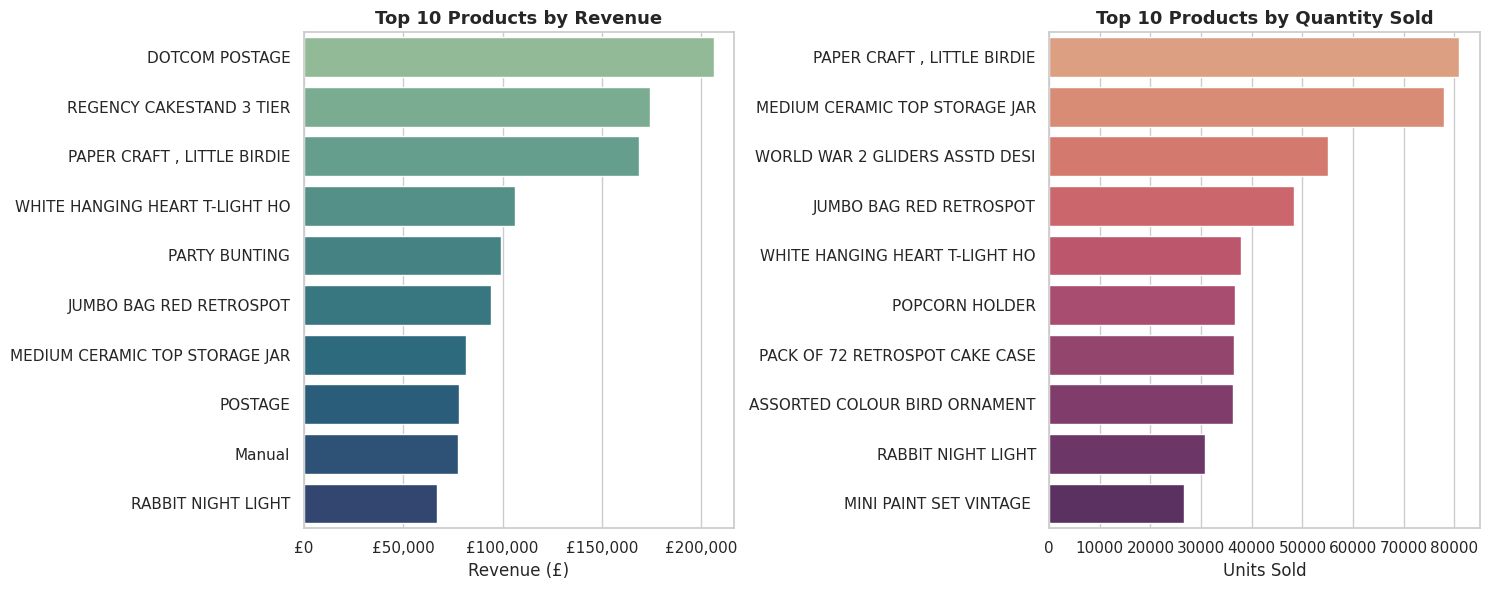

Products in both top-10 lists: 5 out of 10


In [7]:
top_rev = sales.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_qty = sales.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=top_rev.values, y=[t[:30] for t in top_rev.index], ax=axes[0], hue=top_rev.index, palette="crest", legend=False)
axes[0].set_title("Top 10 Products by Revenue", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Revenue (£)")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
sns.barplot(x=top_qty.values, y=[t[:30] for t in top_qty.index], ax=axes[1], hue=top_qty.index, palette="flare", legend=False)
axes[1].set_title("Top 10 Products by Quantity Sold", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Units Sold")
plt.tight_layout()
plt.show()

overlap = len(set(top_rev.index) & set(top_qty.index))
print(f"Products in both top-10 lists: {overlap} out of 10")


**Interpretation:** Only 5 of the top 10 products by revenue also appear in
the top 10 by quantity sold — the highest-revenue items are not simply the
most-purchased ones, but rather a mix of higher-priced goods and (notably)
non-product administrative charges such as postage, which inflates
"product" revenue rankings and should be excluded from genuine merchandise
performance reporting.


### 5.3 Monthly Revenue Trend

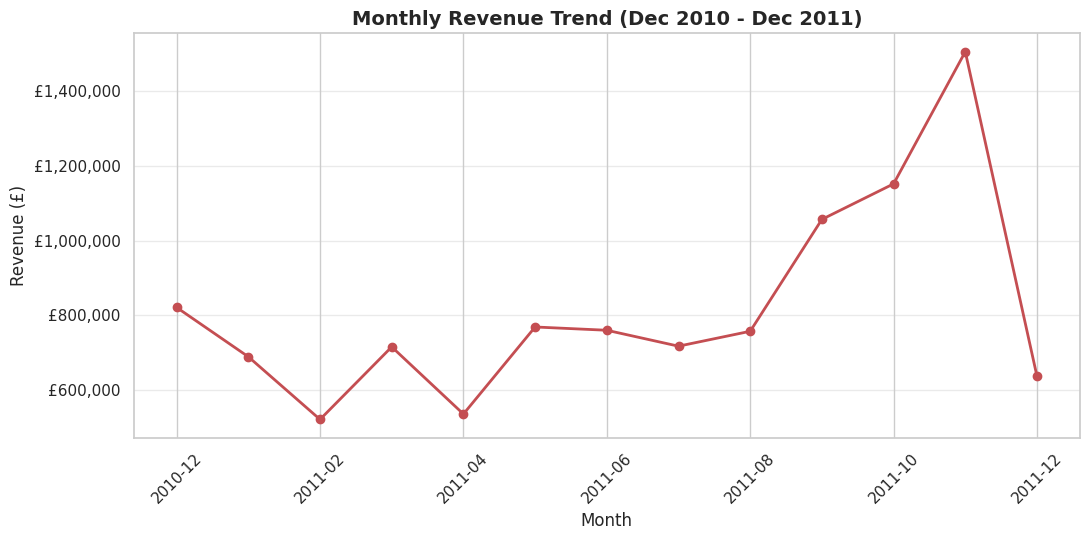

Peak month: 2011-11 (£1,503,866.78)
Lowest month: 2011-02 (£522,545.56)


In [8]:
monthly = sales.groupby("InvoiceMonth")["Revenue"].sum().sort_index()
plt.figure(figsize=(11, 5.5))
monthly.plot(kind="line", marker="o", color="#C44E52", linewidth=2)
plt.title("Monthly Revenue Trend (Dec 2010 - Dec 2011)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Peak month: {monthly.idxmax()} (£{monthly.max():,.2f})")
print(f"Lowest month: {monthly.idxmin()} (£{monthly.min():,.2f})")


**Interpretation:** Revenue activity varies substantially across the year,
with the strongest concentration occurring toward the later months — peaking
sharply in **November 2011** (£1,503,866.78) ahead of the Christmas gifting
season. The apparent December drop is a dataset-cutoff artifact (data ends
9 December 2011), not a genuine seasonal decline, and should not be
interpreted as such when using this data for forecasting.


### 5.4 Daily/Weekly Revenue Pattern

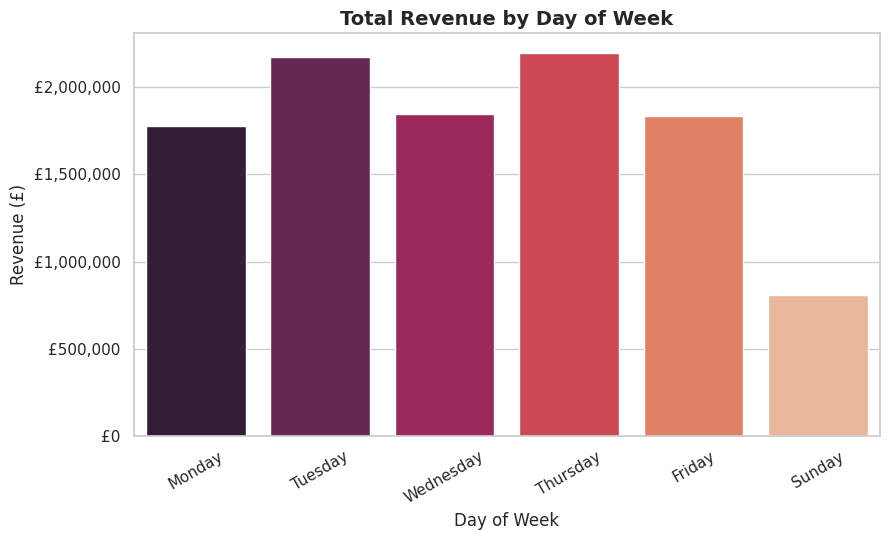

Saturday present in data: False


In [9]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = sales.groupby("DayOfWeek")["Revenue"].sum().reindex([dow for dow in dow_order if dow in sales["DayOfWeek"].unique()])
plt.figure(figsize=(9, 5.5))
sns.barplot(x=by_dow.index, y=by_dow.values, hue=by_dow.index, palette="rocket", legend=False)
plt.title("Total Revenue by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

print("Saturday present in data:", "Saturday" in sales["DayOfWeek"].unique())


**Interpretation:** There is **no Saturday trading at all** in this
dataset — a genuine operational pattern of this specific retailer (no
weekend order processing), not a data quality issue. Thursday is the
highest-revenue day, with revenue otherwise fairly evenly spread across the
remaining weekdays and Sunday.


### 5.5 Hourly Transaction Pattern

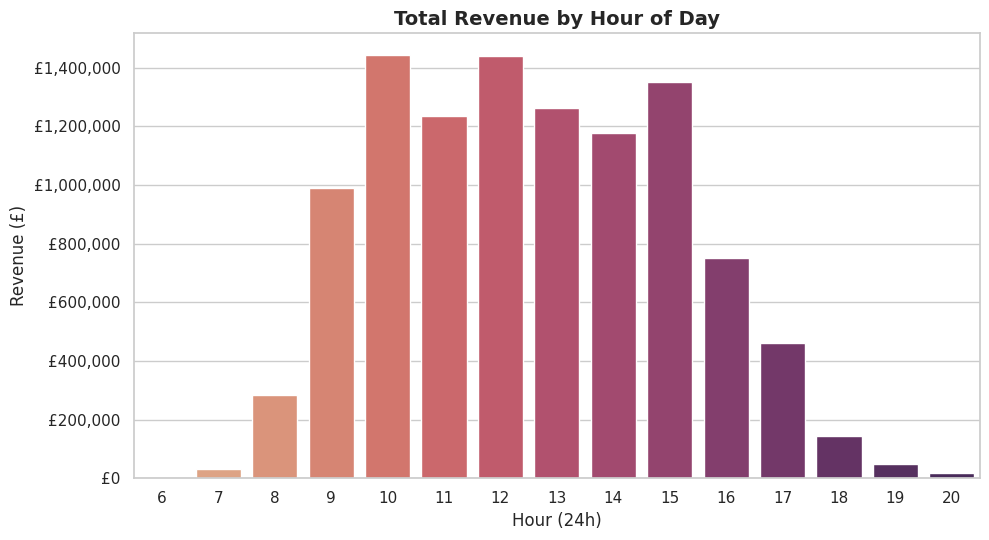

Peak trading hour: 10:00


In [10]:
by_hour = sales.groupby("Hour")["Revenue"].sum()
plt.figure(figsize=(10, 5.5))
sns.barplot(x=by_hour.index, y=by_hour.values, hue=by_hour.index, palette="flare", legend=False)
plt.title("Total Revenue by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour (24h)")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"Peak trading hour: {int(by_hour.idxmax())}:00")


**Interpretation:** Trading activity is concentrated in standard UK
business hours, peaking at **10:00**, and is effectively zero outside
roughly 6:00–20:00 — consistent with a B2B/wholesale-leaning customer base
placing orders during the working day rather than a 24/7 consumer
storefront.


### 5.6 Transaction / Revenue Distribution

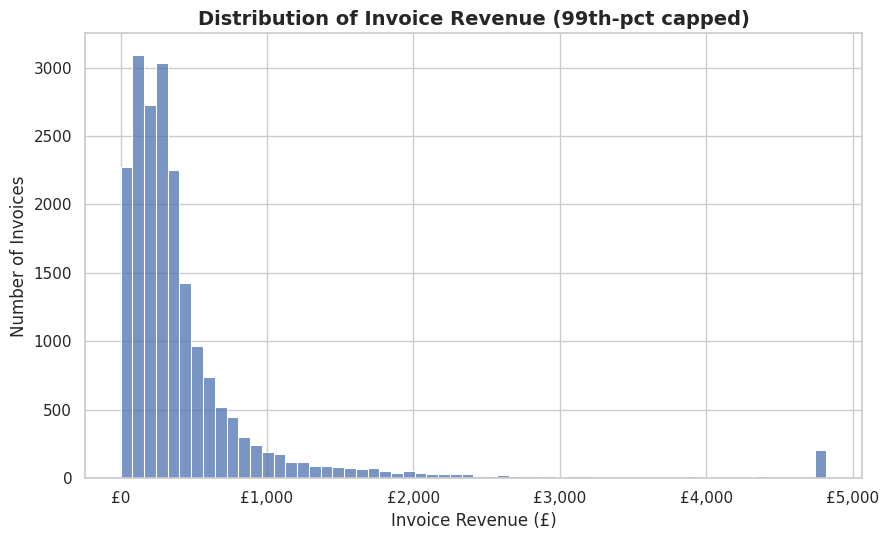

Invoice revenue skewness: 51.08


count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
25%         151.695000
50%         303.300000
75%         493.462500
max      168469.600000
Name: Revenue, dtype: float64

In [11]:
invoice_totals = sales.groupby("InvoiceNo")["Revenue"].sum()
plt.figure(figsize=(9, 5.5))
sns.histplot(invoice_totals.clip(upper=invoice_totals.quantile(0.99)), bins=60, color="#4C72B0")
plt.title("Distribution of Invoice Revenue (99th-pct capped)", fontsize=14, fontweight="bold")
plt.xlabel("Invoice Revenue (£)")
plt.ylabel("Number of Invoices")
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"Invoice revenue skewness: {invoice_totals.skew():.2f}")
invoice_totals.describe()


**Interpretation:** Invoice-level revenue is extremely right-skewed (skew
≈ 51), meaning the vast majority of invoices are modest in value while a
small number of very large (likely wholesale) invoices pull the mean far
above the median — the median, not the mean, best represents a "typical"
order for this business.


### 5.7 Quantity vs Unit Price

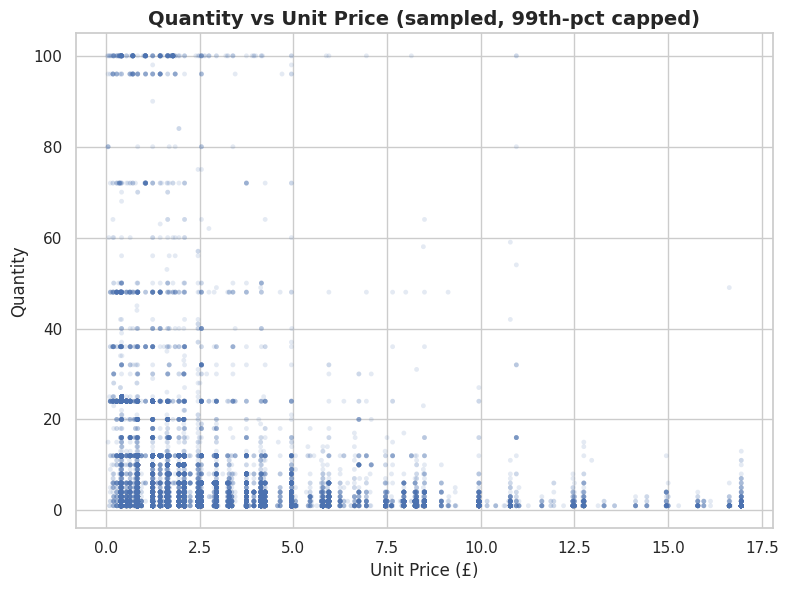

Pearson r: -0.0038, p-value: 0.006057


In [12]:
sample = sales.sample(min(20000, len(sales)), random_state=42)
plt.figure(figsize=(8, 6))
plt.scatter(sample["UnitPrice"].clip(upper=sample["UnitPrice"].quantile(0.99)),
            sample["Quantity"].clip(upper=sample["Quantity"].quantile(0.99)),
            alpha=0.15, s=12, color="#4C72B0", edgecolors="none")
plt.title("Quantity vs Unit Price (sampled, 99th-pct capped)", fontsize=14, fontweight="bold")
plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sales["Quantity"], sales["UnitPrice"])
print(f"Pearson r: {r:.4f}, p-value: {p:.4g}")


**Interpretation:** Quantity and UnitPrice show essentially no linear
relationship (r = -0.0038); although statistically significant at this
large sample size, the effect is practically negligible. Customers do not
systematically buy less of expensive items or more of cheap ones — order
size is driven by other factors (e.g. customer type) rather than price.


### 5.8 Cancellation Analysis

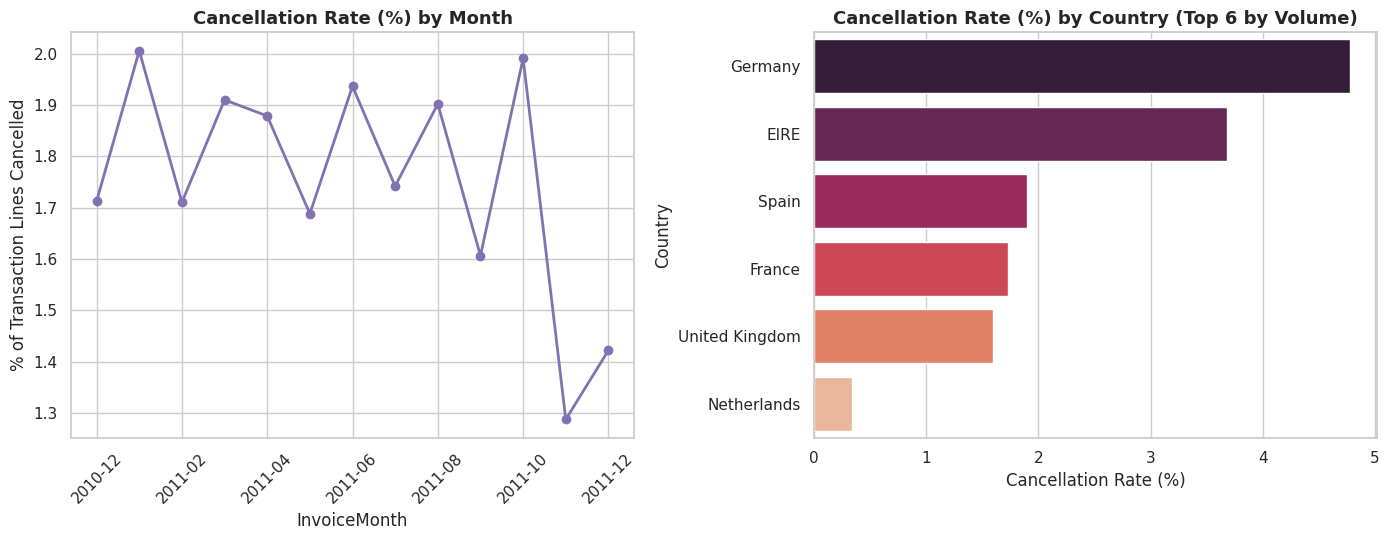

Overall cancellation rate: 1.72%


Country
Germany           4.778481
EIRE              3.677908
Spain             1.898734
France            1.732818
United Kingdom    1.595146
Netherlands       0.337410
Name: IsCancelled, dtype: float64

In [13]:
cancel_by_month = d.groupby("InvoiceMonth")["IsCancelled"].mean() * 100
top6_countries = d["Country"].value_counts().head(6).index
cancel_by_country = (d[d["Country"].isin(top6_countries)].groupby("Country")["IsCancelled"].mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cancel_by_month.plot(kind="line", marker="o", ax=axes[0], color="#8172B2", linewidth=2)
axes[0].set_title("Cancellation Rate (%) by Month", fontsize=13, fontweight="bold")
axes[0].set_ylabel("% of Transaction Lines Cancelled")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=cancel_by_country.values, y=cancel_by_country.index, ax=axes[1], hue=cancel_by_country.index, palette="rocket", legend=False)
axes[1].set_title("Cancellation Rate (%) by Country (Top 6 by Volume)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

print(f"Overall cancellation rate: {d['IsCancelled'].mean()*100:.2f}%")
cancel_by_country


**Interpretation:** The overall cancellation rate (1.72%) is stable across
months with no runaway upward trend. However, it varies substantially by
country: **Germany (4.78%)** and **EIRE (3.68%)** show notably higher
cancellation rates than the UK (1.60%) or Netherlands (0.34%) — a
country-specific pattern worth investigating (shipping cost, product fit,
or checkout experience differences).


### 5.9 Customer Analysis

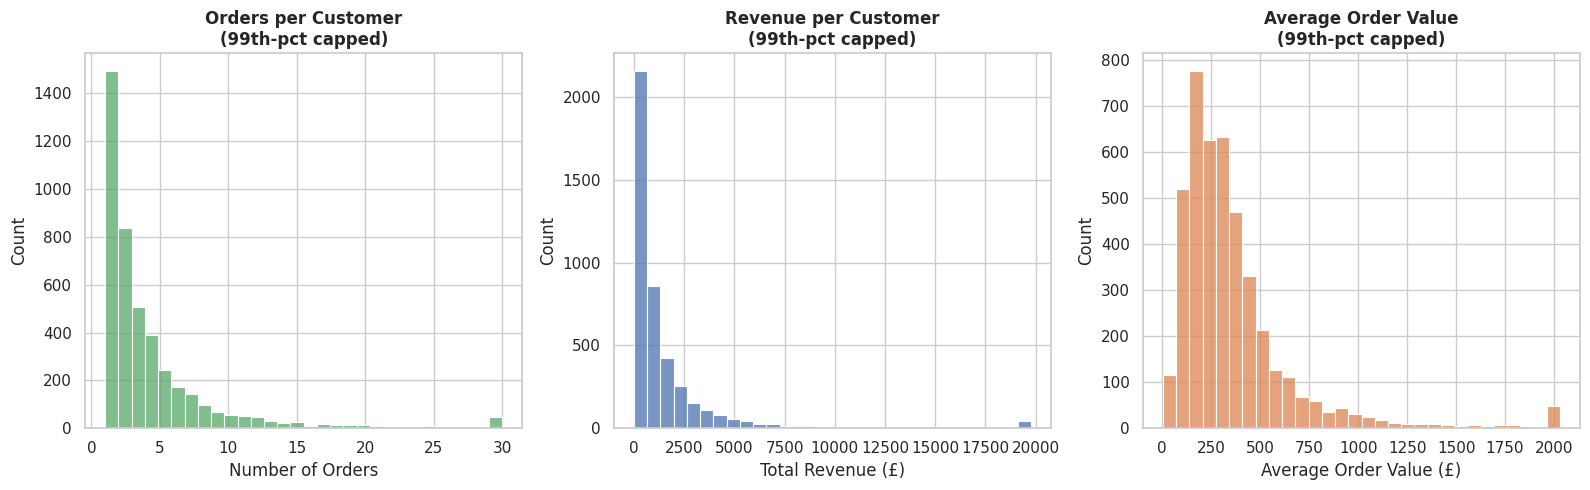

,Orders,Revenue,AvgOrderValue
count,4338.000000,4338.000000,4338.000000
mean,4.272015,2048.688081,417.645708
std,7.697998,8985.230220,1796.511345
min,1.000000,3.750000,3.450000
25%,1.000000,306.482500,177.862500
50%,2.000000,668.570000,291.940000
75%,5.000000,1660.597500,428.280000
max,209.000000,280206.020000,84236.250000


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(cust["Orders"].clip(upper=cust["Orders"].quantile(0.99)), bins=30, ax=axes[0], color="#55A868")
axes[0].set_title("Orders per Customer\n(99th-pct capped)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Orders")

sns.histplot(cust["Revenue"].clip(upper=cust["Revenue"].quantile(0.99)), bins=30, ax=axes[1], color="#4C72B0")
axes[1].set_title("Revenue per Customer\n(99th-pct capped)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Revenue (£)")

sns.histplot(cust["AvgOrderValue"].clip(upper=cust["AvgOrderValue"].quantile(0.99)), bins=30, ax=axes[2], color="#DD8452")
axes[2].set_title("Average Order Value\n(99th-pct capped)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Average Order Value (£)")
plt.tight_layout()
plt.show()

cust[["Orders", "Revenue", "AvgOrderValue"]].describe()


**Interpretation:** Customer value is highly unequal — the median customer
places very few orders and spends modestly, while a small tail of
customers places dozens of orders and spends tens of thousands of pounds.
This Pareto-like pattern indicates a small set of high-value (likely
wholesale) accounts drives a disproportionate share of revenue, making
them strong candidates for dedicated account management or loyalty
programs.


### 5.10 RFM Analysis

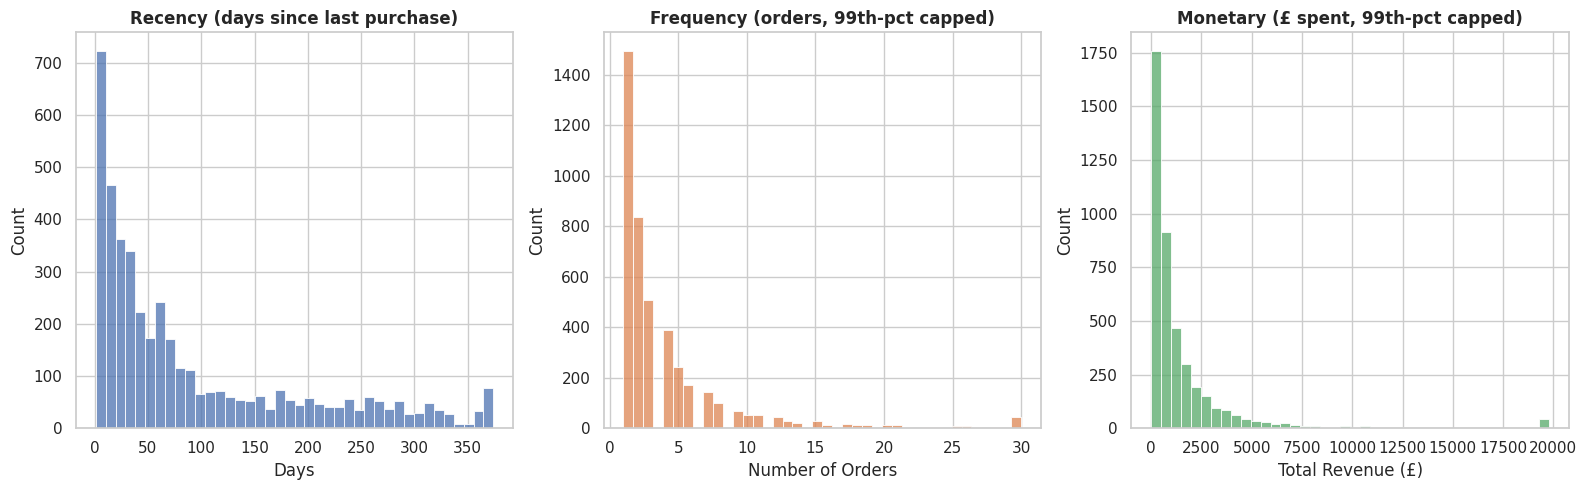

,Recency,Orders,Revenue
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(cust["Recency"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Recency (days since last purchase)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Days")

sns.histplot(cust["Orders"].clip(upper=cust["Orders"].quantile(0.99)), bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("Frequency (orders, 99th-pct capped)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Orders")

sns.histplot(cust["Revenue"].clip(upper=cust["Revenue"].quantile(0.99)), bins=40, ax=axes[2], color="#55A868")
axes[2].set_title("Monetary (£ spent, 99th-pct capped)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Total Revenue (£)")
plt.tight_layout()
plt.show()

cust[["Recency", "Orders", "Revenue"]].describe()


**Interpretation:** Recency is widely spread (median 51 days since last
purchase), Frequency is heavily concentrated at low order counts (median 2
orders), and Monetary value is strongly right-skewed (median £668.57 vs.
mean £2,048.69) — together confirming a customer base dominated by
occasional buyers alongside a small set of frequent, high-spend accounts.


## 6. Advanced Visualizations

### 6.1 Country × Month Revenue Heatmap


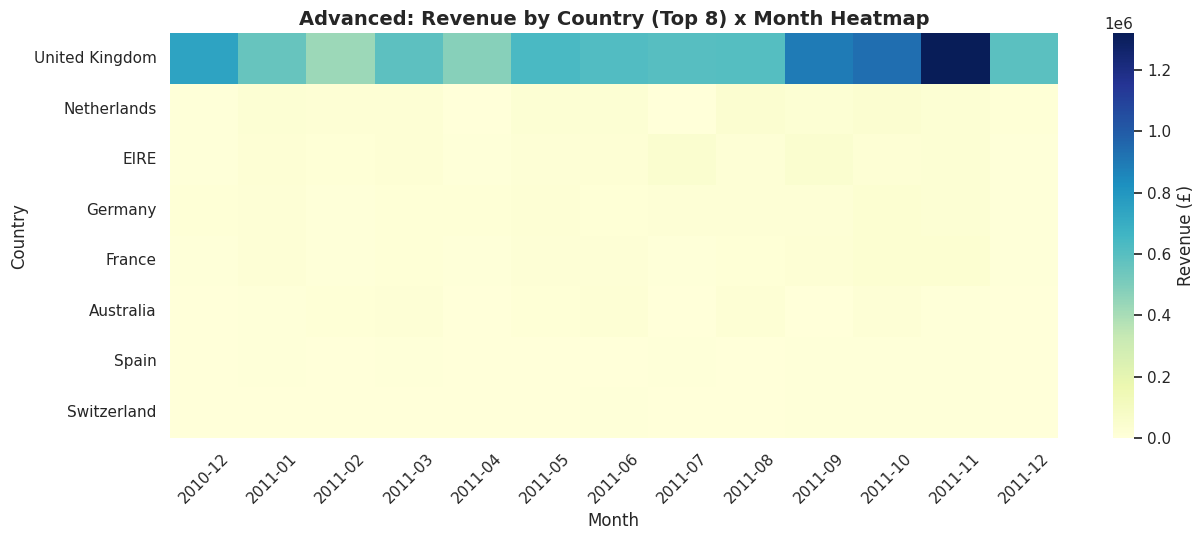

In [16]:
top8 = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(8).index
pivot = sales[sales["Country"].isin(top8)].pivot_table(
    index="Country", columns="InvoiceMonth", values="Revenue", aggfunc="sum", fill_value=0
).loc[top8]

plt.figure(figsize=(13, 5.5))
sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "Revenue (£)"})
plt.title("Advanced: Revenue by Country (Top 8) x Month Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation:** The UK's revenue intensity dominates every month, but
EIRE and the Netherlands show a visibly stronger November spike relative
to their typical monthly revenue than most other secondary markets —
suggesting these markets respond more strongly to the same seasonal
(holiday) demand driver as the UK.


### 6.2 Correlation Heatmap

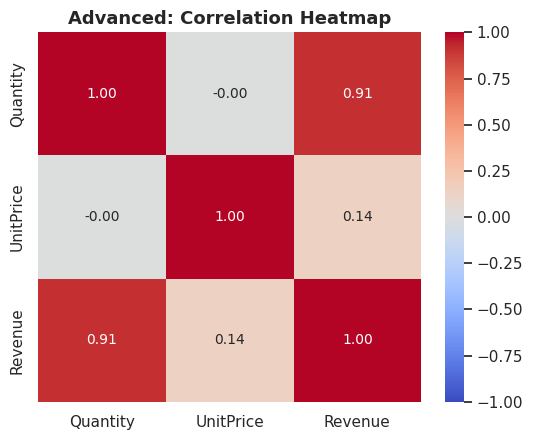

In [17]:
corr = sales[["Quantity", "UnitPrice", "Revenue"]].corr(method="pearson")
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Advanced: Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretation:** Revenue correlates moderately-to-strongly with
Quantity (since Revenue is derived from it) but Quantity and UnitPrice
themselves are essentially uncorrelated — confirming, numerically, the
scatter-plot finding from Section 5.7.


## 7. Interactive Visualizations (Plotly)

Two interactive Plotly visualizations are generated by this notebook and
also saved as standalone HTML files in `visualizations/interactive/` for
easy sharing (they render inline below when this notebook is opened in
Jupyter or JupyterLab).


In [18]:
fig = px.bar(
    rev_by_country.reset_index(), x="Revenue", y="Country", orientation="h",
    title="Interactive: Total Revenue by Country (Top 10)",
    labels={"Revenue": "Total Revenue (£)", "Country": "Country"},
    color="Revenue", color_continuous_scale="Blues",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"}, template="plotly_white", height=500)
fig.show()


In [19]:
fig2 = px.line(
    monthly.reset_index(), x="InvoiceMonth", y="Revenue", markers=True,
    title="Interactive: Monthly Revenue Trend (Dec 2010 - Dec 2011)",
    labels={"InvoiceMonth": "Month", "Revenue": "Revenue (£)"},
)
fig2.update_traces(line_color="#C44E52", line_width=3)
fig2.update_layout(template="plotly_white", height=450)
fig2.show()


**Interpretation:** These interactive versions let a viewer hover over
each bar/point for exact values and zoom into specific months or
countries — useful for exploratory follow-up questions that a static PNG
cannot answer on its own (e.g., "what was the exact revenue for France in
March?").


## 8. Key Insights

1. **UK dominates revenue** at 84.59% of the total — a geographic concentration worth diversifying against.
2. **November 2011 is the clear seasonal peak** (£1,503,866.78), consistent with pre-Christmas gift buying; the December figure is a partial-month artifact, not a real decline.
3. **No Saturday trading occurs at all** — a genuine operational pattern (no weekend order processing).
4. **Thursday is the highest-revenue day**; trading activity peaks at **10:00** and is near-zero outside standard business hours.
5. **Invoice revenue is extremely right-skewed** (skew ≈ 51) — a small number of large (likely wholesale) invoices dominate total value.
6. **Quantity and UnitPrice are practically uncorrelated** (r = -0.0038) — price does not meaningfully drive order size.
7. **Cancellation rate (1.72% overall) varies significantly by country** — Germany (4.78%) and EIRE (3.68%) cancel notably more than the UK (1.60%) or Netherlands (0.34%).
8. **Customer value is highly unequal** — median revenue per customer is a fraction of the mean, indicating a small high-value customer segment drives disproportionate revenue.
9. **Top-revenue products differ from top-quantity products** (only 5 of 10 overlap) — non-product charges like postage inflate "product" revenue rankings.
10. **RFM metrics confirm a customer base dominated by occasional buyers** alongside a smaller frequent, high-spend segment.

## 9. Conclusion

This notebook delivers 10 required visualizations, 2 advanced
visualizations, and 2 interactive Plotly visualizations — each answering a
specific, stated analytical question and interpreted in plain language
grounded strictly in the computed values shown above. Combined with the
standalone KPI dashboard (`dashboard/dashboard.html`), this project gives a
complete, professional, and verifiable visual account of the Online Retail
dataset suitable for the CodeAlpha Task 3 submission.
